# Dataset Exploration

## 1. Counting the total no of images and labels

In [3]:
import os

DATASET_DIR = '../dataset'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
LABELS_DIR = os.path.join(DATASET_DIR, 'labels')

for folder in os.listdir(IMAGES_DIR):
    folder_path = os.path.join(IMAGES_DIR, folder)
    print(f"Count of {folder} images: {len(os.listdir(folder_path))}")

print()
for folder in os.listdir(LABELS_DIR):
    folder_path = os.path.join(LABELS_DIR, folder)
    print(f"Count of {folder} labels: {len(os.listdir(folder_path))}")

Count of test images: 40
Count of train images: 360

Count of train labels: 360


## 2. Checking if every image has its corresponding annotation

In [4]:
train_images = os.listdir(os.path.join(IMAGES_DIR, 'train'))
train_labels = os.listdir(os.path.join(LABELS_DIR, 'train'))

train_image_names = {os.path.splitext(file)[0] for file in train_images}
train_label_names = {os.path.splitext(file)[0] for file in train_labels}

images_without_labels = train_image_names - train_label_names
labels_without_images = train_label_names - train_image_names

print(f"Images without labels: {len(images_without_labels)}")
print(f"Labels without images: {len(labels_without_images)}")

Images without labels: 0
Labels without images: 0


## 3. Counting the total no of solar panels

In [8]:
total_panels = 0
panels_per_image = {}

for label_file in train_labels:
    file_path = os.path.join(os.path.join(LABELS_DIR, 'train'), label_file)

    with open(file_path, "r") as f:
        lines = f.readlines()

    total_panels += len(lines)
    panels_per_image[label_file] = len(lines)

print(f"Total no of solar panels: {total_panels}")

Total no of solar panels: 1051


## 4. Statistics

In [10]:
panel_counts = list(panels_per_image.values())

print(f"Total images: {len(panel_counts)}")
print(f"Total panels: {sum(panel_counts)}")
print(f"Minimum no of panels in an image: {min(panel_counts)}")
print(f"Maximum no of panels in an image: {max(panel_counts)}")
print(f"Average no of panels in an image: {sum(panel_counts) / len(panel_counts):.2f}")

Total images: 360
Total panels: 1051
Minimum no of panels in an image: 0
Maximum no of panels in an image: 20
Average no of panels in an image: 2.92


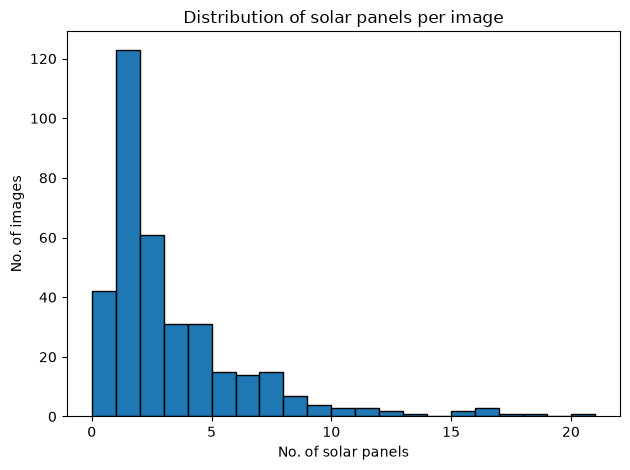

In [12]:
import matplotlib.pyplot as plt

plt.hist(
    panel_counts,
    bins=range(min(panel_counts), max(panel_counts) + 2),
    edgecolor="black"
)

plt.xlabel("No. of solar panels")
plt.ylabel("No. of images")
plt.title("Distribution of solar panels per image")

plt.tight_layout()
plt.show()